In [ ]:
import os
import random
import json
import shutil
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    classification_report, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

CLASSES = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

Device: cuda


In [ ]:
files_to_get = [
    ("https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task3_Training_Input.zip",
     "ISIC2018_Task3_Training_Input.zip"),
    ("https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task3_Training_GroundTruth.zip",
     "ISIC2018_Task3_Training_GroundTruth.zip"),
]

for url, name in files_to_get:
    if not os.path.exists(name):
        print("Downloading:", name)
        urllib.request.urlretrieve(url, name)

os.makedirs("ham10000/images", exist_ok=True)
os.makedirs("ham10000/labels", exist_ok=True)

if not os.listdir("ham10000/images"):
    with zipfile.ZipFile("ISIC2018_Task3_Training_Input.zip", "r") as z:
        z.extractall("ham10000/images")

if not os.listdir("ham10000/labels"):
    with zipfile.ZipFile("ISIC2018_Task3_Training_GroundTruth.zip", "r") as z:
        z.extractall("ham10000/labels")

print("Extracted \u2713")

Downloading: ISIC2018_Task3_Training_Input.zip
Downloading: ISIC2018_Task3_Training_GroundTruth.zip
Extracted ✓


In [ ]:
METADATA_PATH = "HAM10000_metadata.csv"

if not os.path.exists(METADATA_PATH):
    try:
        import kagglehub
        kaggle_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
        for root, dirs, fnames in os.walk(kaggle_path):
            if "HAM10000_metadata.csv" in fnames:
                shutil.copy(os.path.join(root, "HAM10000_metadata.csv"), METADATA_PATH)
                break
    except Exception as e:
        print("Could not auto-download metadata via kagglehub:", e)

assert os.path.exists(METADATA_PATH), (
    f"{METADATA_PATH} not found. Download it manually from Kaggle "
    f"('kmader/skin-cancer-mnist-ham10000') or Harvard Dataverse (HAM10000 release) "
    f"and place it in the working directory before re-running."
)
metadata = pd.read_csv(METADATA_PATH)
print("Metadata loaded \u2713", metadata.shape)


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Metadata loaded ✓ (10015, 7)


In [ ]:
!wget -q --show-progress "https://storage.googleapis.com/kagglestorage/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv"
print("Done ✓")

Done ✓


          image label_name  label  \
0  ISIC_0024306         NV      1   
1  ISIC_0024307         NV      1   
2  ISIC_0024308         NV      1   
3  ISIC_0024309         NV      1   
4  ISIC_0024310        MEL      0   

                                          image_path  
0  ham10000/images/ISIC2018_Task3_Training_Input/...  
1  ham10000/images/ISIC2018_Task3_Training_Input/...  
2  ham10000/images/ISIC2018_Task3_Training_Input/...  
3  ham10000/images/ISIC2018_Task3_Training_Input/...  
4  ham10000/images/ISIC2018_Task3_Training_Input/...  


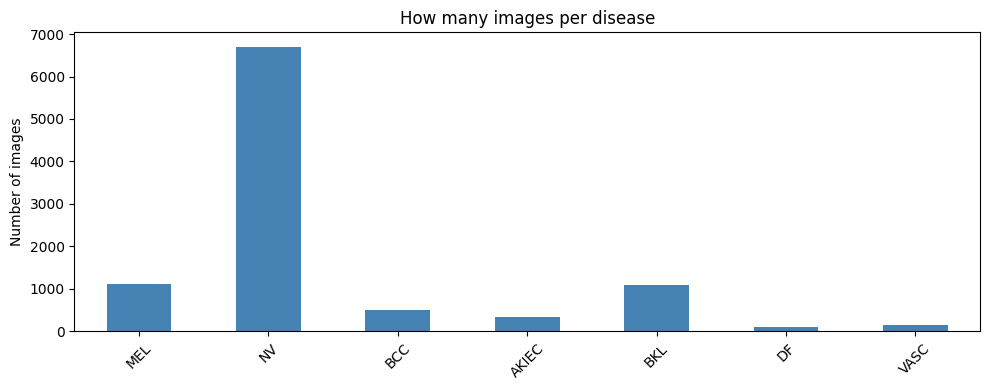

In [ ]:
df = pd.read_csv("ham10000/labels/ISIC2018_Task3_Training_GroundTruth/ISIC2018_Task3_Training_GroundTruth.csv")

df['label_name'] = df[CLASSES].idxmax(axis=1)
df['label'] = df[CLASSES].values.argmax(axis=1)

img_folder = "ham10000/images/ISIC2018_Task3_Training_Input"
df['image_path'] = img_folder + "/" + df['image'] + ".jpg"

print(df[['image', 'label_name', 'label', 'image_path']].head())

plt.figure(figsize=(10, 4))
df[CLASSES].sum().plot(kind='bar', color='steelblue')
plt.title('How many images per disease')
plt.ylabel('Number of images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.4, stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED
)

print(f"Before balancing -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Sanity check: zero image overlap across splits
train_imgs, val_imgs, test_imgs = set(train_df['image']), set(val_df['image']), set(test_df['image'])
assert len(train_imgs & val_imgs) == 0
assert len(train_imgs & test_imgs) == 0
assert len(val_imgs & test_imgs) == 0
print("No leakage between splits \u2713")

# ==========================================================
# Better balancing
# Keep ALL majority class images
# Oversample only minority classes
# ==========================================================
print("Original train distribution:")
print(train_df['label_name'].value_counts())

max_count = train_df['label_name'].value_counts().max()

balanced_train = []

for cls in CLASSES:

    subset = train_df[train_df['label_name'] == cls]

    if len(subset) < max_count:

        subset = resample(
            subset,
            replace=True,
            n_samples=max_count,
            random_state=SEED
        )

    balanced_train.append(subset)

train_df = pd.concat(balanced_train)

train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(train_df['label_name'].value_counts())


Before balancing -> Train: 6009 | Val: 2003 | Test: 2003
No leakage between splits ✓
Original train distribution:
label_name
NV       4023
MEL       668
BKL       660
BCC       308
AKIEC     196
VASC       85
DF         69
Name: count, dtype: int64
label_name
MEL      4023
NV       4023
AKIEC    4023
BKL      4023
BCC      4023
DF       4023
VASC     4023
Name: count, dtype: int64


In [ ]:
def attach_clinical(split_df, metadata):
    merged = split_df.merge(
        metadata[['image_id', 'age', 'sex', 'localization']],
        left_on='image', right_on='image_id', how='left'
    )
    merged['age'] = merged['age'].fillna(merged['age'].median())
    merged['sex'] = merged['sex'].fillna('unknown')
    merged['localization'] = merged['localization'].fillna('unknown')
    return merged


train_df = attach_clinical(train_df, metadata)
val_df = attach_clinical(val_df, metadata)
test_df = attach_clinical(test_df, metadata)

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)
print("Saved train/val/test CSVs \u2713")

Saved train/val/test CSVs ✓


In [ ]:
AGE_MEAN = train_df['age'].mean()
AGE_STD = train_df['age'].std() if train_df['age'].std() > 0 else 1.0
SEX_MAP = {'male': 1.0, 'female': 0.0, 'unknown': 0.5}
LOC_VOCAB = sorted(train_df['localization'].unique().tolist())
LOC_TO_IDX = {loc: i for i, loc in enumerate(LOC_VOCAB)}
UNK_LOC_IDX = len(LOC_VOCAB)
CLINICAL_DIM = 2 + len(LOC_VOCAB) + 1

print(f"Clinical feature size: {CLINICAL_DIM} (localization categories: {len(LOC_VOCAB)})")


def encode_clinical_row(age, sex, localization):
    age_norm = (age - AGE_MEAN) / AGE_STD
    sex_val = SEX_MAP.get(str(sex).lower(), 0.5)
    loc_onehot = np.zeros(len(LOC_VOCAB) + 1, dtype=np.float32)
    loc_onehot[LOC_TO_IDX.get(localization, UNK_LOC_IDX)] = 1.0
    return np.concatenate([[age_norm, sex_val], loc_onehot]).astype(np.float32)


Clinical feature size: 18 (localization categories: 15)


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2),
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class SkinDatasetMultimodal(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self.transform(Image.open(row['image_path']).convert('RGB'))
        clinical = encode_clinical_row(row['age'], row['sex'], row['localization'])
        return img, torch.tensor(clinical), int(row['label'])


train_labels = train_df['label'].values
class_weights_arr = compute_class_weight('balanced', classes=np.arange(len(CLASSES)), y=train_labels)
class_weights = torch.tensor(class_weights_arr, dtype=torch.float).to(DEVICE)
print("Class weights:", dict(zip(CLASSES, class_weights_arr.round(2))))

sampler = WeightedRandomSampler(
    weights=class_weights_arr[train_labels], num_samples=len(train_labels), replacement=True
)

train_loader = DataLoader(SkinDatasetMultimodal(train_df, train_transforms),
                           batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(SkinDatasetMultimodal(val_df, eval_transforms),
                         batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(SkinDatasetMultimodal(test_df, eval_transforms),
                          batch_size=32, shuffle=False, num_workers=2)

print("Data ready \u2713")


Class weights: {'MEL': np.float64(1.0), 'NV': np.float64(1.0), 'BCC': np.float64(1.0), 'AKIEC': np.float64(1.0), 'BKL': np.float64(1.0), 'DF': np.float64(1.0), 'VASC': np.float64(1.0)}
Data ready ✓


In [ ]:
class MultimodalSkinModel(nn.Module):
    def __init__(self, num_classes, clinical_dim, image_backbone='efficientnet_b4'):
        super().__init__()
        self.image_encoder = timm.create_model(image_backbone, pretrained=True, num_classes=0)
        img_dim = self.image_encoder.num_features

        self.clinical_encoder = nn.Sequential(
            nn.Linear(clinical_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(img_dim + 32, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, image, clinical):
        img_feat = self.image_encoder(image)
        clin_feat = self.clinical_encoder(clinical)
        return self.classifier(torch.cat([img_feat, clin_feat], dim=1))



class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):

        ce_loss = nn.functional.cross_entropy(
            inputs,
            targets,
            weight=self.alpha,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)

        loss = ((1 - pt) ** self.gamma) * ce_loss

        return loss.mean()

def get_loss(loss_name):

    if loss_name == "ce":
        return nn.CrossEntropyLoss(weight=class_weights)

    elif loss_name == "focal":
        return FocalLoss(alpha=class_weights)

    else:
        raise ValueError("Unknown loss")

def get_optimizer(model, optimizer_name, lr=1e-4):

    if optimizer_name == "adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=lr
        )

    elif optimizer_name == "adamw":
        return torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=1e-4
        )

    else:
        raise ValueError("Unknown optimizer")

def get_scheduler(optimizer, scheduler_name):

    if scheduler_name == "plateau":

        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2
        )

    elif scheduler_name == "cosine":

        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=10,
            eta_min=1e-6
            )

    else:

        raise ValueError("Unknown scheduler")
scaler = torch.amp.GradScaler("cuda") if torch.cuda.is_available() else None

In [ ]:
# ==========================================================
# TRAINING CONFIG
# ==========================================================

MAX_EPOCHS = 15
PATIENCE = 5

experiments = [
    {
        "name": "Baseline",
        "optimizer": "adam",
        "loss": "ce",
        "scheduler": "plateau"
    },
    {
        "name": "Improved",
        "optimizer": "adamw",
        "loss": "focal",
        "scheduler": "cosine"
    }
]

all_results = []

# ==========================================================
# RUN EXPERIMENTS
# ==========================================================

for exp in experiments:

    print("="*70)
    print("Running:", exp["name"])
    print("="*70)

    model = MultimodalSkinModel(
        len(CLASSES),
        CLINICAL_DIM
    ).to(DEVICE)

    criterion = get_loss(exp["loss"])

    optimizer = get_optimizer(
        model,
        exp["optimizer"]
    )

    scheduler = get_scheduler(
        optimizer,
        exp["scheduler"]
    )

    scaler = torch.amp.GradScaler("cuda") if torch.cuda.is_available() else None

    best_val_f1 = 0
    epochs_no_improve = 0

    history = []

    for epoch in range(MAX_EPOCHS):

        # ================= TRAIN =================

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, clinical, labels in train_loader:

            images = images.to(DEVICE)
            clinical = clinical.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            if scaler is not None:

                with torch.autocast(device_type="cuda"):

                    outputs = model(images, clinical)

                    loss = criterion(outputs, labels)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            else:

                outputs = model(images, clinical)

                loss = criterion(outputs, labels)

                loss.backward()

                optimizer.step()

            running_loss += loss.item()

            pred = outputs.argmax(1)

            correct += (pred == labels).sum().item()

            total += labels.size(0)

        train_acc = 100 * correct / total

        # ================= VALIDATION =================

        model.eval()

        preds = []
        truths = []

        with torch.no_grad():

            for images, clinical, labels in val_loader:

                images = images.to(DEVICE)
                clinical = clinical.to(DEVICE)

                outputs = model(images, clinical)

                pred = outputs.argmax(1)

                preds.extend(pred.cpu().numpy())

                truths.extend(labels.numpy())

        val_acc = accuracy_score(truths, preds) * 100

        val_macro_f1 = f1_score(
            truths,
            preds,
            average="macro"
        )

        val_weighted_f1 = f1_score(
            truths,
            preds,
            average="weighted"
        )

        recalls = recall_score(
            truths,
            preds,
            average=None
        )

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Acc={train_acc:.2f}% | "
            f"Val Acc={val_acc:.2f}% | "
            f"Macro F1={val_macro_f1:.4f}"
        )

        print("Recall:")

        for c, r in zip(CLASSES, recalls):
            print(f"{c:7s}: {r:.3f}")

        # ================= Scheduler =================

        if exp["scheduler"] == "plateau":

            scheduler.step(val_macro_f1)

        else:

            scheduler.step()

        history.append({
            "epoch": epoch + 1,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "macro_f1": val_macro_f1
        })

        # ================= Save Best =================

        if val_macro_f1 > best_val_f1:

            best_val_f1 = val_macro_f1

            epochs_no_improve = 0

            torch.save(
                model.state_dict(),
                f"{exp['name']}_best.pth"
            )

            print("Best model saved.")

        else:

            epochs_no_improve += 1

        # ================= Early Stopping =================

        if epochs_no_improve >= PATIENCE:

            print("Early Stopping")

            break

    all_results.append({
        "Experiment": exp["name"],
        "Best Macro F1": best_val_f1
    })

# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame(all_results)

print(results)

best_exp = results.iloc[
    results["Best Macro F1"].idxmax()
]

print("\nBest Experiment:")
print(best_exp)

Running: Baseline


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Epoch 01 | Train Acc=72.32% | Val Acc=79.48% | Macro F1=0.6884
Recall:
MEL    : 0.640
NV     : 0.858
BCC    : 0.767
AKIEC  : 0.591
BKL    : 0.648
DF     : 0.652
VASC   : 0.862
Best model saved.
Epoch 02 | Train Acc=88.44% | Val Acc=82.93% | Macro F1=0.7452
Recall:
MEL    : 0.658
NV     : 0.887
BCC    : 0.709
AKIEC  : 0.606
BKL    : 0.767
DF     : 0.739
VASC   : 0.966
Best model saved.
Epoch 03 | Train Acc=92.86% | Val Acc=84.62% | Macro F1=0.7648
Recall:
MEL    : 0.743
NV     : 0.911
BCC    : 0.786
AKIEC  : 0.606
BKL    : 0.653
DF     : 0.783
VASC   : 0.931
Best model saved.
Epoch 04 | Train Acc=94.82% | Val Acc=85.87% | Macro F1=0.7908
Recall:
MEL    : 0.761
NV     : 0.914
BCC    : 0.845
AKIEC  : 0.561
BKL    : 0.708
DF     : 0.826
VASC   : 0.931
Best model saved.
Epoch 05 | Train Acc=95.92% | Val Acc=84.32% | Macro F1=0.7846
Recall:
MEL    : 0.806
NV     : 0.895
BCC    : 0.796
AKIEC  : 0.606
BKL    : 0.667
DF     : 0.739
VASC   : 0.862
Epoch 06 | Train Acc=96.93% | Val Acc=86.62% | M

In [ ]:
acc = accuracy_score(truths, preds)
macro_f1 = f1_score(truths, preds, average="macro")

print("\nFinal Test Accuracy:", acc)
print("Final Test Macro F1:", macro_f1)

print(classification_report(truths, preds, target_names=CLASSES))


Final Test Accuracy: 0.8691962056914628
Final Test Macro F1: 0.7862673420360176
              precision    recall  f1-score   support

         MEL       0.65      0.63      0.64       223
          NV       0.92      0.96      0.94      1341
         BCC       0.78      0.81      0.79       103
       AKIEC       0.76      0.63      0.69        65
         BKL       0.82      0.68      0.74       220
          DF       0.89      0.74      0.81        23
        VASC       0.92      0.86      0.89        28

    accuracy                           0.87      2003
   macro avg       0.82      0.76      0.79      2003
weighted avg       0.87      0.87      0.87      2003



In [ ]:
best_exp = results.iloc[results["Best Macro F1"].idxmax()]
best_name = best_exp["Experiment"]
print("Best experiment:", best_name)

Best experiment: Baseline



Loading: Baseline

Final Test Accuracy: 0.8691962056914628
              precision    recall  f1-score   support

         MEL       0.65      0.63      0.64       223
          NV       0.92      0.96      0.94      1341
         BCC       0.78      0.81      0.79       103
       AKIEC       0.76      0.63      0.69        65
         BKL       0.82      0.68      0.74       220
          DF       0.89      0.74      0.81        23
        VASC       0.92      0.86      0.89        28

    accuracy                           0.87      2003
   macro avg       0.82      0.76      0.79      2003
weighted avg       0.87      0.87      0.87      2003



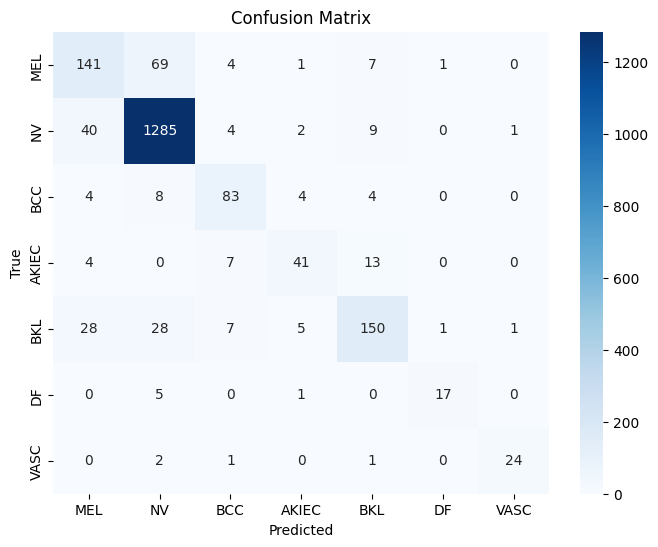

In [ ]:
best_name = best_exp["Experiment"]

print("\nLoading:", best_name)

model = MultimodalSkinModel(
    len(CLASSES),
    CLINICAL_DIM
).to(DEVICE)

model.load_state_dict(
    torch.load(f"{best_name}_best.pth")
)

model.eval()

preds = []
truths = []

with torch.no_grad():

    for images, clinical, labels in test_loader:

        images = images.to(DEVICE)
        clinical = clinical.to(DEVICE)

        outputs = model(images, clinical)

        pred = outputs.argmax(1)

        preds.extend(pred.cpu().numpy())

        truths.extend(labels.numpy())

print("\nFinal Test Accuracy:",
      accuracy_score(truths, preds))

print(classification_report(
    truths,
    preds,
    target_names=CLASSES
))

cm = confusion_matrix(
    truths,
    preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
config = {
    "classes": CLASSES,
    "input_size": 224,
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225],
    "clinical_dim": CLINICAL_DIM,
    "age_mean": float(AGE_MEAN),
    "age_std": float(AGE_STD),
    "sex_map": SEX_MAP,
    "localization_vocab": LOC_VOCAB,
    "best_val_macro_f1": best_val_f1,
    "test_accuracy": acc,
    "test_macro_f1": macro_f1,
}
with open("model_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("\nSaved: multimodal_best.pth, training_history.csv, model_config.json, "
      "train.csv, val.csv, test.csv")
print("\nNext step: run the FastAPI backend (main.py) and open the GUI (index.html) "
      "to test the model interactively.")



Saved: multimodal_best.pth, training_history.csv, model_config.json, train.csv, val.csv, test.csv

Next step: run the FastAPI backend (main.py) and open the GUI (index.html) to test the model interactively.


In [ ]:
!pip install fastapi uvicorn python-multipart pyngrok -q
print("Done \u2713")

Done ✓


In [1]:
%%writefile main.py
from fastapi import FastAPI, UploadFile, File, Form, HTTPException
from fastapi.middleware.cors import CORSMiddleware
import torch
import torch.nn as nn
import timm
import json
import glob
import os
import numpy as np
from PIL import Image, UnidentifiedImageError
from torchvision import transforms
import io

app = FastAPI()

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

# ---- Load config saved during training (encodes exactly how clinical data
#      was normalized/one-hot encoded, so inference matches training) ----
if not os.path.exists("model_config.json"):
    raise FileNotFoundError(
        "model_config.json not found. Re-run the training/config-saving "
        "cells before starting the server."
    )

with open("model_config.json") as f:
    CONFIG = json.load(f)

CLASSES = CONFIG["classes"]
RISK_MAP = {
    'MEL': 'Critical', 'BCC': 'High',
    'AKIEC': 'High', 'BKL': 'Moderate',
    'NV': 'Low', 'DF': 'Low', 'VASC': 'Moderate',
}

AGE_MEAN = CONFIG["age_mean"]
AGE_STD = CONFIG["age_std"]
SEX_MAP = CONFIG["sex_map"]
LOC_VOCAB = CONFIG["localization_vocab"]
LOC_TO_IDX = {loc: i for i, loc in enumerate(LOC_VOCAB)}
UNK_LOC_IDX = len(LOC_VOCAB)
CLINICAL_DIM = CONFIG["clinical_dim"]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def encode_clinical_row(age, sex, localization):
    age_norm = (float(age) - AGE_MEAN) / AGE_STD
    sex_val = SEX_MAP.get(str(sex).lower(), 0.5)
    loc_onehot = np.zeros(len(LOC_VOCAB) + 1, dtype=np.float32)
    loc_idx = LOC_TO_IDX.get(localization, UNK_LOC_IDX)
    loc_onehot[loc_idx] = 1.0
    return np.concatenate([[age_norm, sex_val], loc_onehot]).astype(np.float32)


# ---- Model definition (must match training exactly) ----
class MultimodalSkinModel(nn.Module):
    def __init__(self, num_classes, clinical_dim, image_backbone='efficientnet_b4'):
        super().__init__()
        self.image_encoder = timm.create_model(image_backbone, pretrained=False, num_classes=0)
        img_dim = self.image_encoder.num_features

        self.clinical_encoder = nn.Sequential(
            nn.Linear(clinical_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(img_dim + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, image, clinical):
        img_feat = self.image_encoder(image)
        clin_feat = self.clinical_encoder(clinical)
        combined = torch.cat([img_feat, clin_feat], dim=1)
        return self.classifier(combined)


# ---- Locate the trained checkpoint ----
# The training loop saves "{experiment_name}_best.pth" (e.g. Baseline_best.pth),
# NOT "multimodal_best.pth" — this fallback list finds whichever one actually
# exists on disk instead of hardcoding a filename that's never created.
CANDIDATE_CHECKPOINTS = ["multimodal_best.pth", "Baseline_best.pth", "Improved_best.pth"]
CHECKPOINT_PATH = next((p for p in CANDIDATE_CHECKPOINTS if os.path.exists(p)), None)

if CHECKPOINT_PATH is None:
    found = glob.glob("*_best.pth")
    if found:
        CHECKPOINT_PATH = found[0]

if CHECKPOINT_PATH is None:
    raise FileNotFoundError(
        "No model checkpoint (*_best.pth) found in the working directory. "
        "Re-run the training cell first, or copy the checkpoint here."
    )

print(f"Loading checkpoint: {CHECKPOINT_PATH}")

model = MultimodalSkinModel(num_classes=len(CLASSES), clinical_dim=CLINICAL_DIM)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model = model.to(device)
model.eval()

mean = CONFIG["normalize_mean"]
std = CONFIG["normalize_std"]
size = CONFIG["input_size"]

eval_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

tta_transforms = [
    eval_transform,
    transforms.Compose([
        transforms.Resize((size, size)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]),
    transforms.Compose([
        transforms.Resize((size, size)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]),
]


def predict_with_tta(pil_image, clinical_vec):
    probs_sum = None
    clinical_tensor = torch.tensor(clinical_vec).unsqueeze(0).to(device)
    with torch.no_grad():
        for t in tta_transforms:
            img_tensor = t(pil_image).unsqueeze(0).to(device)
            logits = model(img_tensor, clinical_tensor)
            probs = torch.softmax(logits, dim=1)
            probs_sum = probs if probs_sum is None else probs_sum + probs
    return (probs_sum / len(tta_transforms))[0].cpu().numpy()


@app.get("/")
def home():
    return {
        "status": "Skin Diagnosis API is running",
        "mode": "image + clinical (age, sex, localization)",
        "checkpoint_used": CHECKPOINT_PATH,
        "device": str(device),
        "localization_options": LOC_VOCAB,
        "model_test_macro_f1": CONFIG.get("test_macro_f1"),
    }


@app.get("/health")
def health():
    return {"ok": True}


@app.post("/predict")
async def predict(
    file: UploadFile = File(...),
    age: float = Form(...),
    sex: str = Form(...),
    localization: str = Form(...),
):
    # ---- Validate inputs before touching the model ----
    if not file.content_type or not file.content_type.startswith("image/"):
        raise HTTPException(status_code=400, detail="Uploaded file must be an image.")

    if age < 0 or age > 120:
        raise HTTPException(status_code=400, detail="Age must be between 0 and 120.")

    img_bytes = await file.read()
    if not img_bytes:
        raise HTTPException(status_code=400, detail="Uploaded file is empty.")

    try:
        img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    except UnidentifiedImageError:
        raise HTTPException(status_code=400, detail="File could not be read as an image.")

    try:
        clinical_vec = encode_clinical_row(age, sex, localization)
        probs = predict_with_tta(img, clinical_vec)
    except Exception as e:
        # Surfaces the real cause in the response instead of a bare 500
        raise HTTPException(status_code=500, detail=f"Inference failed: {e}")

    pred_idx = int(np.argmax(probs))
    pred_class = CLASSES[pred_idx]
    confidence = {c: round(float(probs[i]), 3) for i, c in enumerate(CLASSES)}

    return {
        "diagnosis": pred_class,
        "risk_level": RISK_MAP[pred_class],
        "confidence": confidence,
    }

Writing main.py


In [2]:

# =============================================================================
# ---- Cell: print main.py to confirm it was written correctly ----
# =============================================================================
print(open("main.py").read())
print("main.py created \u2713")


from fastapi import FastAPI, UploadFile, File, Form, HTTPException
from fastapi.middleware.cors import CORSMiddleware
import torch
import torch.nn as nn
import timm
import json
import glob
import os
import numpy as np
from PIL import Image, UnidentifiedImageError
from torchvision import transforms
import io

app = FastAPI()

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

# ---- Load config saved during training (encodes exactly how clinical data
#      was normalized/one-hot encoded, so inference matches training) ----
if not os.path.exists("model_config.json"):
    raise FileNotFoundError(
        "model_config.json not found. Re-run the training/config-saving "
        "cells before starting the server."
    )

with open("model_config.json") as f:
    CONFIG = json.load(f)

CLASSES = CONFIG["classes"]
RISK_MAP = {
    'MEL': 'Critical', 'BCC': 'High',
    'AKIEC': 'High', 'BKL': 'Moderate',
    'NV': 'Low', 'DF': 

In [3]:
# =============================================================================
# ---- Cell: write index.html (GUI) ----
# =============================================================================
%%writefile index.html
<!DOCTYPE html>
<html lang="ar" dir="rtl">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Skin Lesion Diagnosis</title>
<style>
  * { box-sizing: border-box; }
  body {
    font-family: 'Segoe UI', Tahoma, Arial, sans-serif;
    background: #f4f6f8;
    margin: 0;
    padding: 0;
    display: flex;
    justify-content: center;
    align-items: flex-start;
    min-height: 100vh;
  }
  .card {
    background: #fff;
    max-width: 480px;
    width: 100%;
    margin: 40px 20px;
    padding: 28px;
    border-radius: 14px;
    box-shadow: 0 4px 20px rgba(0,0,0,0.08);
  }
  h1 { font-size: 20px; color: #1f2937; margin-bottom: 4px; }
  p.subtitle { color: #6b7280; font-size: 13px; margin-top: 0; margin-bottom: 20px; }

  .field { margin-bottom: 14px; }
  .field label { font-size: 12px; color: #6b7280; display:block; margin-bottom: 4px; }
  .field input[type=text], .field input[type=number], .field select {
    width: 100%;
    padding: 9px 10px;
    border: 1px solid #d1d5db;
    border-radius: 8px;
    font-size: 13px;
    font-family: inherit;
  }
  .row2 { display: flex; gap: 10px; }
  .row2 .field { flex: 1; }

  #dropzone {
    border: 2px dashed #cbd5e1;
    border-radius: 10px;
    padding: 22px;
    text-align: center;
    cursor: pointer;
    transition: 0.2s;
    color: #6b7280;
    margin-bottom: 14px;
  }
  #dropzone.dragover { border-color: #3b82f6; background: #eff6ff; }
  #preview { max-width: 100%; margin-bottom: 14px; border-radius: 10px; display: none; }
  input[type=file] { display: none; }

  button {
    width: 100%;
    padding: 12px;
    background: #2563eb;
    color: #fff;
    border: none;
    border-radius: 8px;
    font-size: 15px;
    cursor: pointer;
    transition: 0.2s;
  }
  button:disabled { background: #93c5fd; cursor: not-allowed; }
  button:hover:not(:disabled) { background: #1d4ed8; }

  #result { margin-top: 20px; display: none; }
  .diag-box { padding: 14px; border-radius: 10px; margin-bottom: 12px; }
  .risk-Critical { background: #fee2e2; border: 1px solid #fca5a5; }
  .risk-High     { background: #ffedd5; border: 1px solid #fdba74; }
  .risk-Moderate { background: #fef9c3; border: 1px solid #fde047; }
  .risk-Low      { background: #dcfce7; border: 1px solid #86efac; }
  .diag-title { font-size: 15px; font-weight: 600; margin: 0 0 4px 0; }
  .diag-risk  { font-size: 13px; margin: 0; color: #374151; }
  table { width: 100%; border-collapse: collapse; font-size: 13px; }
  td { padding: 6px 4px; border-bottom: 1px solid #f1f5f9; }
  .bar-bg { background: #e5e7eb; border-radius: 4px; height: 8px; width: 100%; }
  .bar-fill { background: #3b82f6; border-radius: 4px; height: 8px; }

  #error {
    color: #b91c1c;
    background: #fee2e2;
    padding: 10px;
    border-radius: 8px;
    margin-top: 14px;
    font-size: 13px;
    display: none;
  }
  #apiUrlRow { margin-bottom: 18px; }
  .loader { display: none; text-align: center; margin-top: 14px; color: #6b7280; font-size: 13px; }
  .hint { font-size: 11px; color: #9ca3af; margin-top: -8px; margin-bottom: 14px; }

  .symptoms-section {
    border-top: 1px solid #f1f5f9;
    margin-top: 4px;
    padding-top: 16px;
    margin-bottom: 8px;
  }
  .symptoms-title {
    font-size: 13px;
    font-weight: 600;
    color: #374151;
    margin-bottom: 2px;
  }
  .symptoms-desc {
    font-size: 11px;
    color: #9ca3af;
    margin-bottom: 10px;
  }
  .symptom-item {
    display: flex;
    align-items: flex-start;
    gap: 8px;
    padding: 7px 0;
    font-size: 13px;
    color: #374151;
    cursor: pointer;
  }
  .symptom-item input { margin-top: 2px; }
  .symptom-item .sym-sub { display: block; font-size: 11px; color: #9ca3af; }

  .warning-banner {
    display: none;
    padding: 14px;
    border-radius: 10px;
    margin-top: 14px;
    font-size: 13px;
    line-height: 1.6;
  }
  .warning-high {
    background: #fee2e2;
    border: 1px solid #fca5a5;
    color: #7f1d1d;
  }
  .warning-medium {
    background: #fef9c3;
    border: 1px solid #fde047;
    color: #713f12;
  }
  .warning-low {
    background: #f0fdf4;
    border: 1px solid #bbf7d0;
    color: #14532d;
  }
</style>

</head>
<body>

<div class="card">
  <h1>Skin Lesion Diagnosis</h1>
<p class="subtitle">A picture of the skin lesion + patient data gives you a more accurate diagnosis than the multimodal model.</p>

  <div class="field" id="apiUrlRow">
    <label for="apiUrl">API URL (رابط السيرفر / ngrok)</label>
    <input type="text" id="apiUrl" placeholder="https://xxxx.ngrok-free.app/predict" />
  </div>

  <div id="dropzone">
    <p> Drag the pest image here or tap to select </p>
    <input type="file" id="fileInput" accept="image/*" />
  </div>
  <img id="preview" />

  <div class="row2">
    <div class="field">
      <label for="ageInput">age</label>
      <input type="number" id="ageInput" min="0" max="120" placeholder="example: 45" />
    </div>
    <div class="field">
      <label for="sexInput">sex</label>
      <select id="sexInput">
        <option value="male">male</option>
        <option value="female">female</option>
        <option value="unknown">Unspecified </option>
      </select>
    </div>
  </div>

  <div class="field">
    <label for="locInput">Location of injury on the body</label>
    <select id="locInput">
      <option value=""> Loading options from the server... </option>
    </select>
  </div>
  <p class="hint"> These options are automatically loaded from the API to match exactly what the model was trained on.</p>

  <div class="symptoms-section">
    <p class="symptoms-title"> Symptoms you are experiencing (optional)</p>
<p class="symptoms-desc">This is based on the well-known medical ABCDE framework for assessing risk signs, and is completely separate from the model — it appears as an additional alert alongside the model's score, not as part of its training.</p>
    <label class="symptom-item">
      <input type="checkbox" class="symptom-cb" id="sym_asymmetry">
      <span> The shape is asymmetrical <span class="sym-sub">The text of the affliction is not similar to the second text</span></span>
    </label>
    <label class="symptom-item">
      <input type="checkbox" class="symptom-cb" id="sym_border">
      <span> Irregular edges (Border) <span class="sym-sub">Serrated or indistinct edges </span></span>
    </label>
    <label class="symptom-item">
      <input type="checkbox" class="symptom-cb" id="sym_color">
      <span> Multicolor(Color)<span class="sym-sub">More than one color in the same pest</span></span>
    </label>
    <label class="symptom-item">
      <input type="checkbox" class="symptom-cb" id="sym_diameter">
      <span>Diameter greater than 6 mm (Diameter)<span class="sym-sub">About the size of a pencil</span></span>
    </label>
    <label class="symptom-item">
      <input type="checkbox" class="symptom-cb" id="sym_evolving">
      <span>Changes over time (Evolving)<span class="sym-sub">in size, shape, or color overweeks/months </span></span>
    </label>
    <label class="symptom-item">
      <input type="checkbox" class="symptom-cb" id="sym_bleeding">
      <span> Bleeding or leaking fluids </span>
    </label>
    <label class="symptom-item">
      <input type="checkbox" class="symptom-cb" id="sym_itching">
      <span> Persistent itching</span>
    </label>
    <label class="symptom-item">
      <input type="checkbox" class="symptom-cb" id="sym_pain">
      <span>Pain upon touch</span>
    </label>
    <label class="symptom-item">
      <input type="checkbox" class="symptom-cb" id="sym_rapid">
      <span>Appeared or grew rapidly recently</span>
    </label>
  </div>

  <button id="submitBtn" disabled>Get Diagnosis</button>

  <div class="loader" id="loader"> Analyzing in progress...</div>
  <div id="error"></div>

  <div id="result">
    <div id="diagBox" class="diag-box">
      <p class="diag-title" id="diagTitle"></p>
      <p class="diag-risk" id="diagRisk"></p>
    </div>
    <table id="confTable"></table>
    <div id="symptomWarning" class="warning-banner"></div>
  </div>
</div>

<script>
const dropzone    = document.getElementById('dropzone');
const fileInput   = document.getElementById('fileInput');
const preview     = document.getElementById('preview');
const submitBtn   = document.getElementById('submitBtn');
const resultBox   = document.getElementById('result');
const errorBox    = document.getElementById('error');
const loader      = document.getElementById('loader');
const apiUrlInput = document.getElementById('apiUrl');
const ageInput    = document.getElementById('ageInput');
const sexInput    = document.getElementById('sexInput');
const locInput    = document.getElementById('locInput');

let selectedFile = null;

dropzone.addEventListener('click', () => fileInput.click());
dropzone.addEventListener('dragover', (e) => { e.preventDefault(); dropzone.classList.add('dragover'); });
dropzone.addEventListener('dragleave', () => dropzone.classList.remove('dragover'));
dropzone.addEventListener('drop', (e) => {
  e.preventDefault();
  dropzone.classList.remove('dragover');
  if (e.dataTransfer.files.length) handleFile(e.dataTransfer.files[0]);
});
fileInput.addEventListener('change', () => {
  if (fileInput.files.length) handleFile(fileInput.files[0]);
});

function handleFile(file) {
  selectedFile = file;
  const reader = new FileReader();
  reader.onload = (e) => { preview.src = e.target.result; preview.style.display = 'block'; };
  reader.readAsDataURL(file);
  checkReady();
  resultBox.style.display = 'none';
  errorBox.style.display = 'none';
}

function checkReady() {
  submitBtn.disabled = !(selectedFile && ageInput.value && sexInput.value && locInput.value);
}
ageInput.addEventListener('input', checkReady);
sexInput.addEventListener('change', checkReady);
locInput.addEventListener('change', checkReady);

// Load localization options from the API root endpoint once a URL is typed
let lastLoadedBase = null;
apiUrlInput.addEventListener('change', loadLocalizationOptions);
apiUrlInput.addEventListener('blur', loadLocalizationOptions);

async function loadLocalizationOptions() {
  const predictUrl = apiUrlInput.value.trim();
  if (!predictUrl) return;
  const baseUrl = predictUrl.replace(/\/predict\/?$/, '');
  if (baseUrl === lastLoadedBase) return;

  try {
    const res = await fetch(baseUrl + '/', {
      headers: { 'ngrok-skip-browser-warning': 'true' }
    });
    const data = await res.json();
    if (data.localization_options) {
      locInput.innerHTML = '';
      data.localization_options.forEach(opt => {
        const o = document.createElement('option');
        o.value = opt;
        o.textContent = opt;
        locInput.appendChild(o);
      });
      lastLoadedBase = baseUrl;
      checkReady();
    }
  } catch (err) {
    locInput.innerHTML = '<option value="">Options could not be loaded - check the API link</option>';
  }
}

const riskColors = {
  Critical: 'risk-Critical', High: 'risk-High',
  Moderate: 'risk-Moderate', Low: 'risk-Low'
};

submitBtn.addEventListener('click', async () => {
  if (!selectedFile) return;
  const apiUrl = apiUrlInput.value.trim();
  if (!apiUrl) { showError('Please insert the first API link.'); return; }

  errorBox.style.display = 'none';
  resultBox.style.display = 'none';
  loader.style.display = 'block';
  submitBtn.disabled = true;

  const formData = new FormData();
  formData.append('file', selectedFile);
  formData.append('age', ageInput.value);
  formData.append('sex', sexInput.value);
  formData.append('localization', locInput.value);

  try {
    const res = await fetch(apiUrl, {
      method: 'POST',
      headers: { 'ngrok-skip-browser-warning': 'true' },
      body: formData
    });
    if (!res.ok) throw new Error('Server returned status ' + res.status);
    const data = await res.json();
    renderResult(data);
  } catch (err) {
    showError('An error occurred connecting to the server:'+ err.message);
  } finally {
    loader.style.display = 'none';
    submitBtn.disabled = false;
  }
});

function showError(msg) {
  errorBox.textContent = msg;
  errorBox.style.display = 'block';
}

function renderResult(data) {
  const diagBox   = document.getElementById('diagBox');
  const diagTitle = document.getElementById('diagTitle');
  const diagRisk  = document.getElementById('diagRisk');
  const confTable = document.getElementById('confTable');

  diagBox.className = 'diag-box ' + (riskColors[data.risk_level] || '');
  diagTitle.textContent = 'Diagnosis: ' + data.diagnosis;
  diagRisk.textContent  = 'Risk level (from the model):' + data.risk_level;

  confTable.innerHTML = '';
  const sorted = Object.entries(data.confidence).sort((a, b) => b[1] - a[1]);
  for (const [cls, val] of sorted) {
    const pct = Math.round(val * 100);
    const row = document.createElement('tr');
    row.innerHTML = `
      <td style="width:60px">${cls}</td>
      <td><div class="bar-bg"><div class="bar-fill" style="width:${pct}%"></div></div></td>
      <td style="width:40px; text-align:left">${pct}%</td>
    `;
    confTable.appendChild(row);
  }
  resultBox.style.display = 'block';

  renderSymptomWarning();
}

// -----------------------------------------------------------------------
// Symptom-based clinical warning (ABCDE rule) - COMPLETELY SEPARATE from
// the trained model. This is a simple rule-based score, not a prediction.
// It is shown alongside the model's output, never merged into it.
// -----------------------------------------------------------------------
function renderSymptomWarning() {
  const symptomIds = [
    'sym_asymmetry', 'sym_border', 'sym_color', 'sym_diameter', 'sym_evolving',
    'sym_bleeding', 'sym_itching', 'sym_pain', 'sym_rapid'
  ];

  const checked = symptomIds.filter(id => document.getElementById(id).checked);
  const warningBox = document.getElementById('symptomWarning');

  if (checked.length === 0) {
    warningBox.style.display = 'none';
    return;
  }

  // ABCDE core signs (asymmetry, border, color, diameter, evolving) carry
  // more clinical weight than the general symptoms (bleeding/itch/pain/rapid).
  const abcdeIds = ['sym_asymmetry', 'sym_border', 'sym_color', 'sym_diameter', 'sym_evolving'];
  const abcdeCount = checked.filter(id => abcdeIds.includes(id)).length;
  const otherCount = checked.length - abcdeCount;
  const score = abcdeCount * 2 + otherCount;

  let level, cls, message;
  if (score >= 5) {
    level = 'high';
    cls = 'warning-high';
   message = 'The symptoms you identified match several warning signs from the ABCDE medical assessment for melanoma.'

+ 'This is a symptom-based alert only (not from the model), and you are advised to see a dermatologist as soon as possible.'

+ 'Even if the model above showed a low-risk result.'
  } else if (score >= 2) {
    level = 'medium';
    cls = 'warning-medium';
message = 'There are some signs that need to be monitored. It is recommended to consult a dermatologist for reassurance, especially if these symptoms are new or changing.'  } else {
    level = 'low';
    cls = 'warning-low';
message = 'Specific symptoms are limited, but any noticeable change in any skin lesion warrants follow-up with a doctor.'  }

  warningBox.className = 'warning-banner ' + cls;
warningBox.innerHTML = `<strong>Symptom Alert (Level ${level}):</strong><br>${message}`;  warningBox.style.display = 'block';
}
</script>

</body>
</html>


Writing index.html


In [5]:
!pip install pyngrok -q

In [6]:
#Get a free token from https://dashboard.ngrok.com/get-started/your-authtoken
from pyngrok import ngrok
ngrok.set_auth_token("3G0gcwdYnk9MiDnGMWFLbS5kGT3_7bSSpV4Joen3Un6VbfSYw")


In [7]:
import subprocess, time

server_process = subprocess.Popen(
    ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]
)
time.sleep(5)

public_url = ngrok.connect(8000)
print("API URL:", public_url)
print("Use this in the GUI's 'API URL' field, with /predict added at the end:")
print(str(public_url) + "/predict")

API URL: NgrokTunnel: "https://player-carat-cahoots.ngrok-free.dev" -> "http://localhost:8000"
Use this in the GUI's 'API URL' field, with /predict added at the end:
NgrokTunnel: "https://player-carat-cahoots.ngrok-free.dev" -> "http://localhost:8000"/predict


In [8]:
from google.colab import files
files.download("index.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>